In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go 
from plotly.subplots import make_subplots

# <font color='violet'>DATASET LOADING</font>

In [32]:
df = pd.read_csv("2019-Oct.csv")

# <font color='violet'>basic operations</font>

In [34]:
#reducing the size of dataset (this is not a good practise but my laptop may crash or take excess time)
# get unique sessions
unique_sessions = df['user_session'].unique()

# sample sessions (adjust n to land near your target row count)
sampled_sessions = pd.Series(unique_sessions).sample(n=40000, random_state=42)

# keep all rows belonging to sampled sessions
df = df[df['user_session'].isin(sampled_sessions)]

print(df.shape)

(183098, 9)


In [35]:
df.to_csv('sample_dataset(200k).csv',index=False)

In [2]:
#loading dataset 
df = pd.read_csv('sample_dataset(200k).csv')

In [37]:
print('data:->')
print(df.head())
print()
print('--------------------------------------------------------------------------------------------------')

print('datatypes:-> ')
print(df.info())
print()
print('---------------------------------------------------------------------------------------------------')

print('discripption:-> ')
print(df.describe(include='all'))
print()
print('---------------------------------------------------------------------------------------------------')

print('shape:-> ')
print(df.shape)
print()
print('---------------------------------------------------------------------------------------------------')

print('null count:-> ')
print(df.isnull().sum())
print()
print('---------------------------------------------------------------------------------------------------')

print('duplicate count:-> ')
print(df.duplicated().sum())
print()
print('---------------------------------------------------------------------------------------------------')

data:->
                event_time event_type  product_id          category_id  \
0  2019-10-01 02:24:33 UTC       view     5100376  2053013553341792533   
1  2019-10-01 02:25:18 UTC       view     5100435  2053013553341792533   
2  2019-10-01 02:26:07 UTC       view     5100435  2053013553341792533   
3  2019-10-01 02:26:35 UTC       view     5100675  2053013553341792533   
4  2019-10-01 02:27:20 UTC       view    12718062  2053013553559896355   

        category_code   brand   price    user_id  \
0  electronics.clocks  xiaomi   68.01  541505850   
1  electronics.clocks  garmin  135.95  541505850   
2  electronics.clocks  garmin  135.95  541505850   
3  electronics.clocks  xiaomi  135.14  541505850   
4                 NaN     NaN   32.43  541505850   

                           user_session  
0  18e33284-0448-4b84-9769-75b6fd1a65ef  
1  18e33284-0448-4b84-9769-75b6fd1a65ef  
2  18e33284-0448-4b84-9769-75b6fd1a65ef  
3  18e33284-0448-4b84-9769-75b6fd1a65ef  
4  18e33284-0448-4b84-97

# <font color='violet'>Data Cleaning </font> 

In [3]:
#removing duplicates 
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [4]:
#handling null values of brands column 
df['brand'] = df['brand'].fillna('unknown_brand') 
df['category_code'] = df['category_code'].fillna('unknown_category')
df.isnull().sum()

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64

In [5]:
#seprating date and time of events 
df['event_date'] = df['event_time'].str.split(' ').str[0]   # '2019-10-01'
df['event_time_only'] = df['event_time'].str.split(' ').str[1]  # '02:24:33'

In [6]:
#cleaning category_code 
df['category_code'].unique()

array(['electronics.clocks', 'unknown_category', 'electronics.smartphone',
       'auto.accessories.videoregister',
       'appliances.kitchen.refrigerators', 'computers.desktop',
       'auto.accessories.player', 'furniture.kitchen.table',
       'appliances.kitchen.grill', 'construction.tools.welding',
       'electronics.audio.headphone', 'apparel.shoes', 'kids.dolls',
       'furniture.bedroom.bed', 'computers.components.memory',
       'furniture.living_room.cabinet', 'accessories.wallet',
       'appliances.sewing_machine', 'appliances.environment.vacuum',
       'electronics.video.projector', 'accessories.bag',
       'appliances.kitchen.oven', 'computers.components.cpu',
       'appliances.kitchen.washer', 'appliances.environment.air_heater',
       'apparel.underwear', 'electronics.tablet',
       'appliances.kitchen.blender', 'electronics.video.tv',
       'appliances.kitchen.meat_grinder', 'electronics.telephone',
       'construction.tools.drill', 'sport.bicycle',
       'c

In [7]:
split_cols = df['category_code'].str.split('.')
df['category_top'] = split_cols.str[0]                          # broad: furniture, electronics
df['category_sub'] = split_cols.str[-1] 
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_time_only,category_top,category_sub
0,2019-10-01 02:24:33 UTC,view,5100376,2053013553341792533,electronics.clocks,xiaomi,68.01,541505850,18e33284-0448-4b84-9769-75b6fd1a65ef,2019-10-01,02:24:33,electronics,clocks
1,2019-10-01 02:25:18 UTC,view,5100435,2053013553341792533,electronics.clocks,garmin,135.95,541505850,18e33284-0448-4b84-9769-75b6fd1a65ef,2019-10-01,02:25:18,electronics,clocks
2,2019-10-01 02:26:07 UTC,view,5100435,2053013553341792533,electronics.clocks,garmin,135.95,541505850,18e33284-0448-4b84-9769-75b6fd1a65ef,2019-10-01,02:26:07,electronics,clocks
3,2019-10-01 02:26:35 UTC,view,5100675,2053013553341792533,electronics.clocks,xiaomi,135.14,541505850,18e33284-0448-4b84-9769-75b6fd1a65ef,2019-10-01,02:26:35,electronics,clocks
4,2019-10-01 02:27:20 UTC,view,12718062,2053013553559896355,unknown_category,unknown_brand,32.43,541505850,18e33284-0448-4b84-9769-75b6fd1a65ef,2019-10-01,02:27:20,unknown_category,unknown_category


In [8]:
#removing unneccesary columns now 
df = df.drop(columns=['event_time','category_code'])
df = df.rename(columns={'event_time_only':'event_time'})
df['event_time'].head()

0    02:24:33
1    02:25:18
2    02:26:07
3    02:26:35
4    02:27:20
Name: event_time, dtype: object

In [9]:
df['event_type'].unique()

array(['view', 'purchase', 'cart'], dtype=object)

In [10]:
#defining event column 
def defining(event_to_define):
    if event_to_define =='view':
        return 'Product_View'
    elif event_to_define == 'cart': 
        return 'Add_To_Cart'
    return 'Purchase'

df['event_type'] = df['event_type'].apply(defining)
df['event_type'].unique()

array(['Product_View', 'Purchase', 'Add_To_Cart'], dtype=object)

# <font color='violet'>Calculation Overall Convertion Rates </font> 

In [11]:
#making session-level funnel table 
funnel = df.groupby('user_session')['event_type'].apply(lambda x: set(x)).reset_index()

funnel['Viewed'] = funnel['event_type'].apply(lambda x: 'Product_View' in x)
funnel['Added_To_Cart'] = funnel['event_type'].apply(lambda x: 'Add_To_Cart' in x)
funnel['Purchased'] = funnel['event_type'].apply(lambda x: 'Purchase' in x)

In [12]:
#calculation view->cart convertion
vtc  = funnel[(funnel['Viewed']==True) & (funnel['Added_To_Cart']==True)].shape[0]
v = funnel[funnel['Viewed']==True].shape[0]
view_to_cart = (vtc/v)*100
print(f'View → Cart Conversion: {view_to_cart:.2f}%')

#calculating cart->purchase convertion
ctp  = funnel[(funnel['Added_To_Cart']==True) & (funnel['Purchased']==True)].shape[0]
c = funnel[funnel['Added_To_Cart']==True].shape[0]
cart_to_purchase = (ctp/c)*100
print(f'Cart → Purchase Conversion: {cart_to_purchase:.2f}%')

#calculation view->purchased convertion
vtp  = funnel[(funnel['Viewed']==True) & (funnel['Purchased']==True)].shape[0]
v = funnel[funnel['Viewed']==True].shape[0]
view_to_purchase = (vtp/v)*100
print(f'View → Purchase (Overall) Conversion: {view_to_purchase:.2f}%')

View → Cart Conversion: 6.19%
Cart → Purchase Conversion: 49.98%
View → Purchase (Overall) Conversion: 6.82%


# <font color='violet'> Calculation TOP 5 Convertion Rate According to Category_Top </font> 

In [13]:
# Product View sessions
views = df[df['event_type'] == 'Product_View']

# Add to Cart sessions
carts = df[df['event_type'] == 'Add_To_Cart']

# Purchase sessions
purchases = df[df['event_type'] == 'Purchase']

In [14]:
#common view cart session
view_cart = pd.merge(
    views[['user_session', 'category_top']],
    carts[['user_session', 'category_top']],
    on=['user_session', 'category_top']
)
view_cart_count = view_cart.groupby('category_top')['user_session'].nunique()

#common cart purchase sessions 
cart_purchase = pd.merge(
    carts[['user_session', 'category_top']],
    purchases[['user_session', 'category_top']],
    on=['user_session', 'category_top']
) 
cart_purchase_count = cart_purchase.groupby('category_top')['user_session'].nunique()

#total views,carts,purchase count 
view_count = views.groupby('category_top')['user_session'].nunique()
cart_count = carts.groupby('category_top')['user_session'].nunique() 
purchase_count = purchases.groupby('category_top')['user_session'].nunique()

#making a dataframe to calculate convertion 
funnel_category_top = pd.DataFrame({
    'Views': view_count,
    'Carts': cart_count,
    'Purchases' : purchase_count,
    'View_to_Cart_sessions': view_cart_count,
    'Cart_to_Purchase_sessions': cart_purchase_count
}) 

funnel_category_top['View_to_Cart'] = (
    funnel_category_top['View_to_Cart_sessions']
    / funnel_category_top['Views']
) * 100 

funnel_category_top['Cart_to_Purchase'] = (
    funnel_category_top['Cart_to_Purchase_sessions']
    / funnel_category_top['Carts']
) * 100 

funnel_category_top['View_to_Purchase'] = (
    funnel_category_top['Cart_to_Purchase_sessions']
    / funnel_category_top['Views']
) * 100 

funnel_category_top

#we will not fix NAN because if we do 0 at those places then convertion can go inf 


,Views,Carts,Purchases,View_to_Cart_sessions,Cart_to_Purchase_sessions,View_to_Cart,Cart_to_Purchase,View_to_Purchase
category_top,,,,,,,,
accessories,288,NaN,7.0,NaN,NaN,NaN,NaN,NaN
apparel,1583,NaN,35.0,NaN,NaN,NaN,NaN,NaN
appliances,4482,254.0,294.0,253.0,113.0,5.644801,44.488189,2.521196
auto,1206,31.0,57.0,31.0,15.0,2.570481,48.387097,1.243781
computers,2185,64.0,103.0,64.0,29.0,2.929062,45.312500,1.327231
construction,756,31.0,32.0,31.0,16.0,4.100529,51.612903,2.116402
country_yard,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
electronics,18329,1797.0,1528.0,1794.0,932.0,9.787768,51.864218,5.084838
furniture,1453,6.0,26.0,6.0,2.0,0.412939,33.333333,0.137646


In [15]:
#calculation top 5 category_tops for view->cart 
top5_category_top_vtc = funnel_category_top.sort_values(by='View_to_Cart',ascending=False)['View_to_Cart'].head(5)
print(top5_category_top_vtc) 
print('============================================================')
print()

#calculation top 5 category_tops for cart->purchase 
top5_category_top_ctp = funnel_category_top.sort_values(by='Cart_to_Purchase',ascending=False)['Cart_to_Purchase'].head(5)
print(top5_category_top_ctp) 
print('============================================================')
print()

#calculation top 5 category_tops for view->cart 
top5_category_top_vtp = funnel_category_top.sort_values(by='View_to_Purchase',ascending=False)['View_to_Purchase'].head(5)
print(top5_category_top_vtp) 
print('============================================================')
print()

category_top
medicine        15.789474
electronics      9.787768
appliances       5.644801
construction     4.100529
computers        2.929062
Name: View_to_Cart, dtype: float64

category_top
sport           75.000000
medicine        66.666667
kids            55.555556
electronics     51.864218
construction    51.612903
Name: Cart_to_Purchase, dtype: float64

category_top
medicine        10.526316
electronics      5.084838
appliances       2.521196
construction     2.116402
computers        1.327231
Name: View_to_Purchase, dtype: float64



# <font color='violet'> Calculation TOP 5 Convertion Rate According to Category_Sub </font> 

In [16]:
# common view-cart sessions
view_cart = pd.merge(
    views[['user_session', 'category_sub']],
    carts[['user_session', 'category_sub']],
    on=['user_session', 'category_sub']
)

view_cart_count = view_cart.groupby('category_sub')['user_session'].nunique()


# common cart-purchase sessions
cart_purchase = pd.merge(
    carts[['user_session', 'category_sub']],
    purchases[['user_session', 'category_sub']],
    on=['user_session', 'category_sub']
)

cart_purchase_count = cart_purchase.groupby('category_sub')['user_session'].nunique()


# total views, carts, purchase count
view_count = views.groupby('category_sub')['user_session'].nunique()
cart_count = carts.groupby('category_sub')['user_session'].nunique()
purchase_count = purchases.groupby('category_sub')['user_session'].nunique()


# making a dataframe to calculate conversion
funnel_category_sub = pd.DataFrame({
    'Views': view_count,
    'Carts': cart_count,
    'Purchases': purchase_count,
    'View_to_Cart_sessions': view_cart_count,
    'Cart_to_Purchase_sessions': cart_purchase_count
})


# View -> Cart conversion
funnel_category_sub['View_to_Cart'] = (
    funnel_category_sub['View_to_Cart_sessions']
    / funnel_category_sub['Views']
) * 100


# Cart -> Purchase conversion
funnel_category_sub['Cart_to_Purchase'] = (
    funnel_category_sub['Cart_to_Purchase_sessions']
    / funnel_category_sub['Carts']
) * 100


# View -> Purchase conversion
funnel_category_sub['View_to_Purchase'] = (
    funnel_category_sub['Cart_to_Purchase_sessions']
    / funnel_category_sub['Views']
) * 100


funnel_category_sub

,Views,Carts,Purchases,View_to_Cart_sessions,Cart_to_Purchase_sessions,View_to_Cart,Cart_to_Purchase,View_to_Purchase
category_sub,,,,,,,,
acoustic,154,2.0,2.0,2.0,1.0,1.298701,50.000000,0.649351
air_conditioner,46,NaN,2.0,NaN,NaN,NaN,NaN,NaN
air_heater,138,7.0,8.0,7.0,3.0,5.072464,42.857143,2.173913
alarm,292,13.0,14.0,13.0,9.0,4.452055,69.230769,3.082192
bag,245,NaN,5.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
wallet,54,NaN,2.0,NaN,NaN,NaN,NaN,NaN
washer,941,60.0,58.0,60.0,25.0,6.376196,41.666667,2.656748
water_heater,172,13.0,11.0,13.0,4.0,7.558140,30.769231,2.325581


In [46]:
#calculation top 5 category_tops for view->cart 
top5_category_sub_vtc = funnel_category_sub.sort_values(by='View_to_Cart',ascending=False)['View_to_Cart'].head(5)
print(top5_category_sub_vtc) 
print('============================================================')
print()

#calculation top 5 category_tops for cart->purchase 
top5_category_sub_ctp = funnel_category_sub.sort_values(by='Cart_to_Purchase',ascending=False)['Cart_to_Purchase'].head(5)
print(top5_category_sub_ctp) 
print('============================================================')
print()

#calculation top 5 category_tops for view->purchase
top5_category_sub_vtp = funnel_category_sub.sort_values(by='View_to_Purchase',ascending=False)['View_to_Purchase'].head(5)
print(top5_category_sub_vtp) 
print('============================================================')
print()

category_sub
tonometer     15.789474
camera        12.500000
smartphone    10.694548
headphone      9.382872
tv             9.194467
Name: View_to_Cart, dtype: float64

category_sub
bicycle           100.0
light             100.0
steam_cooker      100.0
coffee_machine    100.0
motherboard       100.0
Name: Cart_to_Purchase, dtype: float64

category_sub
tonometer      10.526316
smartphone      5.772965
hdd             5.194805
hair_cutter     5.000000
swing           4.761905
Name: View_to_Purchase, dtype: float64



# <font color='violet'> Calculation TOP 5 Convertion Rate According to brand name </font>  

In [18]:
# common view-cart sessions
view_cart = pd.merge(
    views[['user_session', 'brand']],
    carts[['user_session', 'brand']],
    on=['user_session', 'brand']
)

view_cart_count = view_cart.groupby('brand')['user_session'].nunique()


# common cart-purchase sessions
cart_purchase = pd.merge(
    carts[['user_session', 'brand']],
    purchases[['user_session', 'brand']],
    on=['user_session', 'brand']
)

cart_purchase_count = cart_purchase.groupby('brand')['user_session'].nunique()


# total views, carts, purchase count
view_count = views.groupby('brand')['user_session'].nunique()
cart_count = carts.groupby('brand')['user_session'].nunique()
purchase_count = purchases.groupby('brand')['user_session'].nunique()


# making a dataframe to calculate conversion
funnel_brand = pd.DataFrame({
    'Views': view_count,
    'Carts': cart_count,
    'Purchases': purchase_count,
    'View_to_Cart_sessions': view_cart_count,
    'Cart_to_Purchase_sessions': cart_purchase_count
})


# View -> Cart conversion
funnel_brand['View_to_Cart'] = (
    funnel_brand['View_to_Cart_sessions']
    / funnel_brand['Views']
) * 100


# Cart -> Purchase conversion
funnel_brand['Cart_to_Purchase'] = (
    funnel_brand['Cart_to_Purchase_sessions']
    / funnel_brand['Carts']
) * 100


# View -> Purchase conversion
funnel_brand['View_to_Purchase'] = (
    funnel_brand['Cart_to_Purchase_sessions']
    / funnel_brand['Views']
) * 100


funnel_brand

,Views,Carts,Purchases,View_to_Cart_sessions,Cart_to_Purchase_sessions,View_to_Cart,Cart_to_Purchase,View_to_Purchase
brand,,,,,,,,
a-case,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a-mega,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abtoys,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acer,631,29.0,31.0,29.0,14.0,4.595880,48.275862,2.2187
achilles,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
zotac,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zte,24,1.0,NaN,1.0,NaN,4.166667,NaN,NaN
zubr,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
#calculation top 5 category_tops for view->cart 
top5_brand_vtc = funnel_brand.sort_values(by='View_to_Cart',ascending=False)['View_to_Cart'].head(5)
print(top5_brand_vtc) 
print('============================================================')
print()

#calculation top 5 category_tops for cart->purchase 
top5_brand_ctp = funnel_brand.sort_values(by='Cart_to_Purchase',ascending=False)['Cart_to_Purchase'].head(5)
print(top5_brand_ctp) 
print('============================================================')
print()

#calculation top 5 category_tops for view->cart 
top5_brand_vtp = funnel_brand.sort_values(by='View_to_Purchase',ascending=False)['View_to_Purchase'].head(5)
print(top5_brand_vtp) 
print('============================================================')
print()

brand
diamond     33.333333
adata       25.000000
ea          22.727273
domyos      20.000000
gigawatt    20.000000
Name: View_to_Cart, dtype: float64

brand
epson        100.0
teploross    100.0
phoenix      100.0
horizont     100.0
inoi         100.0
Name: Cart_to_Purchase, dtype: float64

brand
diamond    33.333333
adata      25.000000
jetpik     16.666667
brother    12.500000
ea         11.363636
Name: View_to_Purchase, dtype: float64



# <font color='violet'> Calculation TOP 5 Convertion Rate According to Product_id </font> 

In [20]:
# common view-cart sessions
view_cart = pd.merge(
    views[['user_session', 'product_id']],
    carts[['user_session', 'product_id']],
    on=['user_session', 'product_id']
)

view_cart_count = view_cart.groupby('product_id')['user_session'].nunique()


# common cart-purchase sessions
cart_purchase = pd.merge(
    carts[['user_session', 'product_id']],
    purchases[['user_session', 'product_id']],
    on=['user_session', 'product_id']
)

cart_purchase_count = cart_purchase.groupby('product_id')['user_session'].nunique()


# total views, carts and purchases
view_count = views.groupby('product_id')['user_session'].nunique()

cart_count = carts.groupby('product_id')['user_session'].nunique()

purchase_count = purchases.groupby('product_id')['user_session'].nunique()


# making dataframe to calculate conversion
funnel_product = pd.DataFrame({
    'Views': view_count,
    'Carts': cart_count,
    'Purchases': purchase_count,
    'View_to_Cart_sessions': view_cart_count,
    'Cart_to_Purchase_sessions': cart_purchase_count
})


# View -> Cart conversion
funnel_product['View_to_Cart'] = (
    funnel_product['View_to_Cart_sessions']
    / funnel_product['Views']
) * 100


# Cart -> Purchase conversion
funnel_product['Cart_to_Purchase'] = (
    funnel_product['Cart_to_Purchase_sessions']
    / funnel_product['Carts']
) * 100


# View -> Purchase conversion
funnel_product['View_to_Purchase'] = (
    funnel_product['Cart_to_Purchase_sessions']
    / funnel_product['Views']
) * 100


funnel_product

,Views,Carts,Purchases,View_to_Cart_sessions,Cart_to_Purchase_sessions,View_to_Cart,Cart_to_Purchase,View_to_Purchase
product_id,,,,,,,,
1000978,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1001588,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1002042,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1002062,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1002098,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
60000025,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60400006,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60500001,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
#calculation top 5 category_tops for view->cart 
top5_product_vtc = funnel_product.sort_values(by='View_to_Cart',ascending=False)['View_to_Cart'].head(5)
print(top5_product_vtc) 
print('============================================================')
print()

#calculation top 5 category_tops for cart->purchase 
top5_product_ctp = funnel_product.sort_values(by='Cart_to_Purchase',ascending=False)['Cart_to_Purchase'].head(5)
print(top5_product_ctp) 
print('============================================================')
print()

#calculation top 5 category_tops for view->cart 
top5_product_vtp = funnel_product.sort_values(by='View_to_Purchase',ascending=False)['View_to_Purchase'].head(5)
print(top5_product_vtp) 
print('============================================================')
print()

product_id
7600550     100.0
12707854    100.0
8901897     100.0
9000118     100.0
9100834     100.0
Name: View_to_Cart, dtype: float64

product_id
3100491    100.0
3801304    100.0
4501359    100.0
4501329    100.0
4500281    100.0
Name: Cart_to_Purchase, dtype: float64

product_id
11000200    100.0
3701574     100.0
13000000    100.0
11300054    100.0
11200317    100.0
Name: View_to_Purchase, dtype: float64



# <font color='violet'>Drop-Off analysis of category_top </font> 

In [22]:
funnel_category_top['View_to_Cart_Dropoff'] = (100 - funnel_category_top['View_to_Cart'])
funnel_category_top['Cart_to_Purchase_Dropoff'] = (100 - funnel_category_top['Cart_to_Purchase'])
funnel_category_top['View_to_Purchase_Dropoff'] = (100 - funnel_category_top['View_to_Purchase'])
funnel_category_top[['View_to_Cart_Dropoff','Cart_to_Purchase_Dropoff','View_to_Purchase_Dropoff']]

,View_to_Cart_Dropoff,Cart_to_Purchase_Dropoff,View_to_Purchase_Dropoff
category_top,,,
accessories,NaN,NaN,NaN
apparel,NaN,NaN,NaN
appliances,94.355199,55.511811,97.478804
auto,97.429519,51.612903,98.756219
computers,97.070938,54.687500,98.672769
construction,95.899471,48.387097,97.883598
country_yard,NaN,NaN,NaN
electronics,90.212232,48.135782,94.915162
furniture,99.587061,66.666667,99.862354


In [23]:
#calculation top 5 category_tops for view->cart 
top5_category_top_vtc_do = funnel_category_top.sort_values(by='View_to_Cart_Dropoff',ascending=False)['View_to_Cart_Dropoff'].head(5)
print(top5_category_top_vtc) 
print('============================================================')
print()

#calculation top 5 category_tops for cart->purchase 
top5_category_top_ctp_do = funnel_category_top.sort_values(by='Cart_to_Purchase_Dropoff',ascending=False)['Cart_to_Purchase_Dropoff'].head(5)
print(top5_category_top_ctp_do) 
print('============================================================')
print()

#calculation top 5 category_tops for view->cart 
top5_category_top_vtp_do = funnel_category_top.sort_values(by='View_to_Purchase_Dropoff',ascending=False)['View_to_Purchase_Dropoff'].head(5)
print(top5_category_top_vtp_do) 
print('============================================================')
print()

category_top
medicine        15.789474
electronics      9.787768
appliances       5.644801
construction     4.100529
computers        2.929062
Name: View_to_Cart, dtype: float64

category_top
furniture           66.666667
unknown_category    57.328990
appliances          55.511811
computers           54.687500
auto                51.612903
Name: Cart_to_Purchase_Dropoff, dtype: float64

category_top
furniture           99.862354
kids                99.277457
unknown_category    99.101879
sport               98.804781
auto                98.756219
Name: View_to_Purchase_Dropoff, dtype: float64



# <font color='violet'>Drop-Off analysis of category_sub </font>  

In [24]:
funnel_category_sub['View_to_Cart_Dropoff'] = (100 - funnel_category_sub['View_to_Cart'])
funnel_category_sub['Cart_to_Purchase_Dropoff'] = (100 - funnel_category_sub['Cart_to_Purchase'])
funnel_category_sub['View_to_Purchase_Dropoff'] = (100 - funnel_category_sub['View_to_Purchase'])
funnel_category_sub[['View_to_Cart_Dropoff','Cart_to_Purchase_Dropoff','View_to_Purchase_Dropoff']]

,View_to_Cart_Dropoff,Cart_to_Purchase_Dropoff,View_to_Purchase_Dropoff
category_sub,,,
acoustic,98.701299,50.000000,99.350649
air_conditioner,NaN,NaN,NaN
air_heater,94.927536,57.142857,97.826087
alarm,95.547945,30.769231,96.917808
bag,NaN,NaN,NaN
...,...,...,...
wallet,NaN,NaN,NaN
washer,93.623804,58.333333,97.343252
water_heater,92.441860,69.230769,97.674419


In [25]:
#calculation top 5 category_subs for view->cart dropoff
top5_category_sub_vtc_do = funnel_category_sub.sort_values(by='View_to_Cart_Dropoff',ascending=False)['View_to_Cart_Dropoff'].head(5)
print(top5_category_sub_vtc_do) 
print('============================================================')
print()

#calculation top 5 category_subs for cart->purchase dropoff
top5_category_sub_ctp_do = funnel_category_sub.sort_values(by='Cart_to_Purchase_Dropoff',ascending=False)['Cart_to_Purchase_Dropoff'].head(5)
print(top5_category_sub_ctp_do) 
print('============================================================')
print()

#calculation top 5 category_subs for view->cart dropoff
top5_category_sub_vtp_do = funnel_category_sub.sort_values(by='View_to_Purchase_Dropoff',ascending=False)['View_to_Purchase_Dropoff'].head(5)
print(top5_category_sub_vtp_do) 
print('============================================================')
print()

category_sub
table         99.447514
bed           99.382716
skates        99.290780
chair         99.190283
videocards    99.152542
Name: View_to_Cart_Dropoff, dtype: float64

category_sub
videoregister    85.714286
kettle           83.333333
toster           75.000000
meat_grinder     75.000000
scales           71.428571
Name: Cart_to_Purchase_Dropoff, dtype: float64

category_sub
videoregister    99.687500
carriage         99.600000
bed              99.588477
desktop          99.567100
kettle           99.534884
Name: View_to_Purchase_Dropoff, dtype: float64



# <font color='violet'>Drop-Off analysis of brand </font>   

In [26]:
funnel_brand['View_to_Cart_Dropoff'] = (100 - funnel_brand['View_to_Cart'])
funnel_brand['Cart_to_Purchase_Dropoff'] = (100 - funnel_brand['Cart_to_Purchase'])
funnel_brand['View_to_Purchase_Dropoff'] = (100 - funnel_brand['View_to_Purchase'])
funnel_brand[['View_to_Cart_Dropoff','Cart_to_Purchase_Dropoff','View_to_Purchase_Dropoff']]

,View_to_Cart_Dropoff,Cart_to_Purchase_Dropoff,View_to_Purchase_Dropoff
brand,,,
a-case,NaN,NaN,NaN
a-mega,NaN,NaN,NaN
abtoys,NaN,NaN,NaN
acer,95.404120,51.724138,97.7813
achilles,NaN,NaN,NaN
...,...,...,...
zotac,NaN,NaN,NaN
zte,95.833333,NaN,NaN
zubr,NaN,NaN,NaN


In [27]:
#calculation top 5 brand for view->cart dropoff
top5_brand_vtc_do = funnel_brand.sort_values(by='View_to_Cart_Dropoff',ascending=False)['View_to_Cart_Dropoff'].head(5)
print(top5_brand_vtc_do) 
print('============================================================')
print()

#calculation top 5 brand for cart->purchase dropoff
top5_brand_ctp_do = funnel_brand.sort_values(by='Cart_to_Purchase_Dropoff',ascending=False)['Cart_to_Purchase_Dropoff'].head(5)
print(top5_brand_ctp_do) 
print('============================================================')
print()

#calculation top 5 brand for view->cart dropoff
top5_brand_vtp_do = funnel_brand.sort_values(by='View_to_Purchase_Dropoff',ascending=False)['View_to_Purchase_Dropoff'].head(5)
print(top5_brand_vtp_do) 
print('============================================================')
print()

brand
triangle         99.742931
pioneer          99.672131
atlant           99.378882
unknown_brand    99.374474
meizu            99.303136
Name: View_to_Cart_Dropoff, dtype: float64

brand
dauscher    83.333333
kingston    80.000000
candy       80.000000
oasis       75.000000
lenovo      75.000000
Name: Cart_to_Purchase_Dropoff, dtype: float64

brand
dauscher         99.831650
lenovo           99.791232
unknown_brand    99.747384
triangle         99.742931
meizu            99.651568
Name: View_to_Purchase_Dropoff, dtype: float64



# <font color='violet'>Drop-Off analysis of product </font> 

In [28]:
funnel_product['View_to_Cart_Dropoff'] = (100 - funnel_product['View_to_Cart'])
funnel_product['Cart_to_Purchase_Dropoff'] = (100 - funnel_product['Cart_to_Purchase'])
funnel_product['View_to_Purchase_Dropoff'] = (100 - funnel_product['View_to_Purchase'])
funnel_product[['View_to_Cart_Dropoff','Cart_to_Purchase_Dropoff','View_to_Purchase_Dropoff']]

,View_to_Cart_Dropoff,Cart_to_Purchase_Dropoff,View_to_Purchase_Dropoff
product_id,,,
1000978,NaN,NaN,NaN
1001588,NaN,NaN,NaN
1002042,NaN,NaN,NaN
1002062,NaN,NaN,NaN
1002098,NaN,NaN,NaN
...,...,...,...
60000025,NaN,NaN,NaN
60400006,NaN,NaN,NaN
60500001,NaN,NaN,NaN


In [29]:
#calculation top 5 brand for view->cart dropoff
top5_product_vtc_do = funnel_product.sort_values(by='View_to_Cart_Dropoff',ascending=False)['View_to_Cart_Dropoff'].head(5)
print(top5_product_vtc_do) 
print('============================================================')
print()

#calculation top 5 brand for cart->purchase dropoff
top5_product_ctp_do = funnel_product.sort_values(by='Cart_to_Purchase_Dropoff',ascending=False)['Cart_to_Purchase_Dropoff'].head(5)
print(top5_product_ctp_do) 
print('============================================================')
print()

#calculation top 5 brand for view->cart dropoff
top5_product_vtp_do = funnel_product.sort_values(by='View_to_Purchase_Dropoff',ascending=False)['View_to_Purchase_Dropoff'].head(5)
print(top5_product_vtp_do) 
print('============================================================')
print()

product_id
1005239    99.259259
1005015    99.065421
5701166    98.734177
1005021    98.734177
1005186    98.666667
Name: View_to_Cart_Dropoff, dtype: float64

product_id
4803977     83.333333
1005008     83.333333
1004957     83.333333
1004240     80.000000
16400025    80.000000
Name: Cart_to_Purchase_Dropoff, dtype: float64

product_id
1004957    99.363057
1003317    99.358974
4802036    99.354839
1005239    99.259259
1004794    99.206349
Name: View_to_Purchase_Dropoff, dtype: float64



# <font color='pink'>Funnel Drop off chart </font>

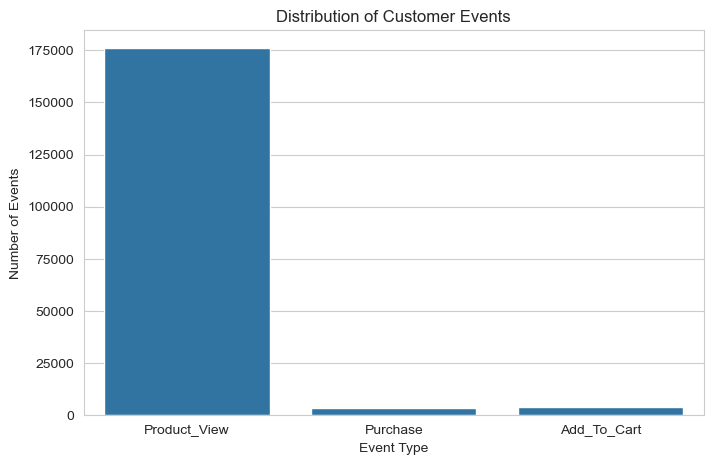

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='event_type')

plt.title('Distribution of Customer Events')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')

plt.show()

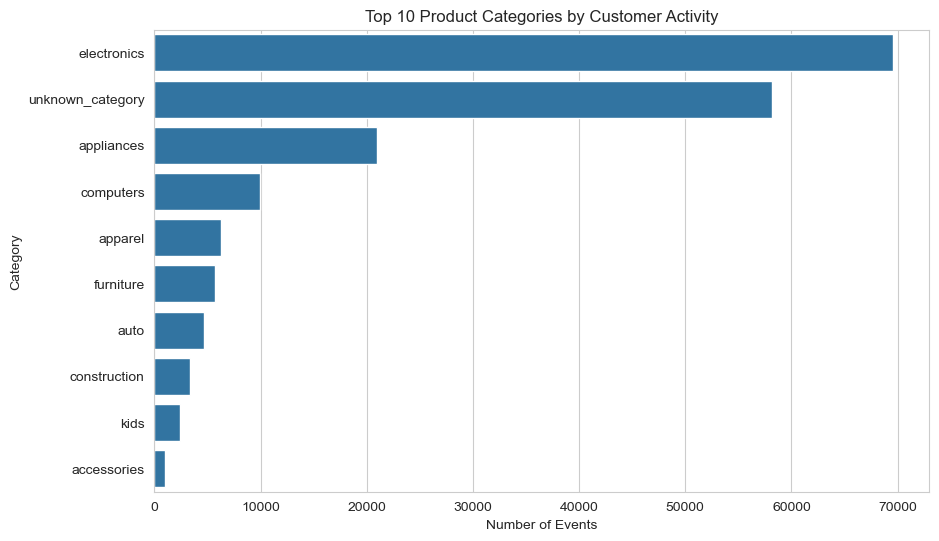

In [36]:
#top 10 product category 
plt.figure(figsize=(10,6))

top_categories = df['category_top'].value_counts().head(10)

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title('Top 10 Product Categories by Customer Activity')
plt.xlabel('Number of Events')
plt.ylabel('Category')

plt.show()

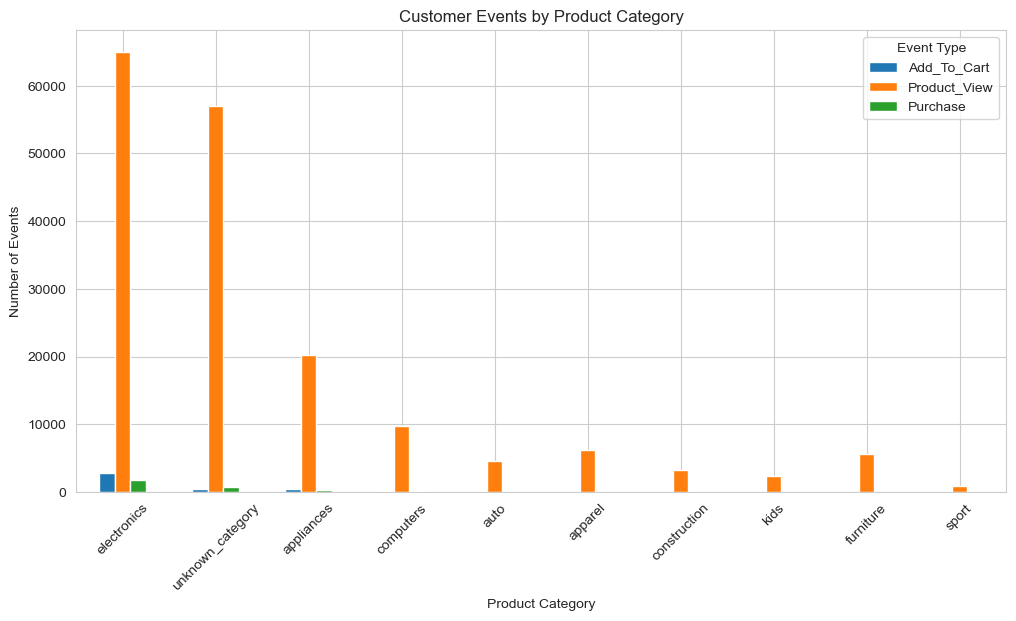

In [37]:
#event type by category 
category_event = pd.crosstab(
    df['category_top'],
    df['event_type']
)

category_event = category_event.sort_values(
    by='Purchase',
    ascending=False
).head(10)

category_event.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Customer Events by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Events')

plt.xticks(rotation=45)
plt.legend(title='Event Type')

plt.show()

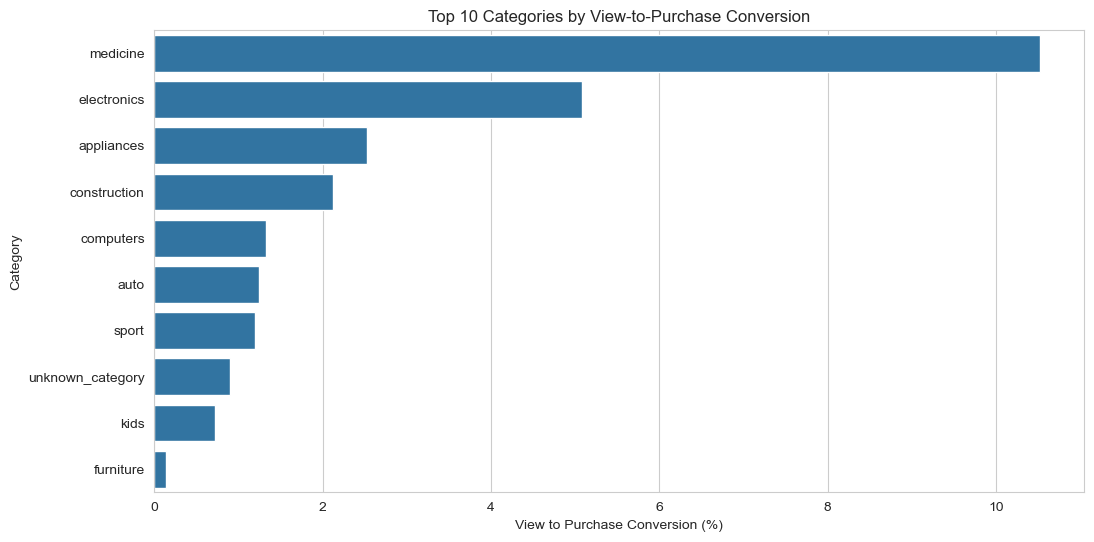

In [42]:
#top5 category_top by  view->purchase convertion
plt.figure(figsize=(12,6))

sns.barplot(
    data=funnel_category_top.sort_values(
        'View_to_Purchase',
        ascending=False
    ).head(10),
    x='View_to_Purchase',
    y='category_top'
)

plt.title('Top 10 Categories by View-to-Purchase Conversion')
plt.xlabel('View to Purchase Conversion (%)')
plt.ylabel('Category')

plt.show()


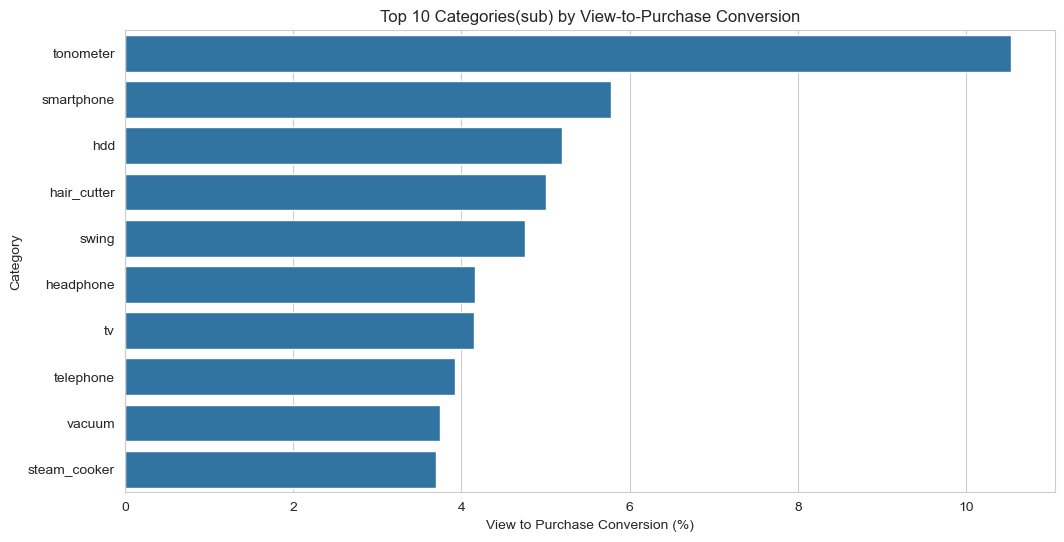

In [45]:
#top5 category_top by  view->purchase convertion
plt.figure(figsize=(12,6))

sns.barplot(
    data=funnel_category_sub.sort_values(
        'View_to_Purchase',
        ascending=False
    ).head(10),
    x='View_to_Purchase',
    y='category_sub'
)

plt.title('Top 10 Categories(sub) by View-to-Purchase Conversion')
plt.xlabel('View to Purchase Conversion (%)')
plt.ylabel('Category')

plt.show()

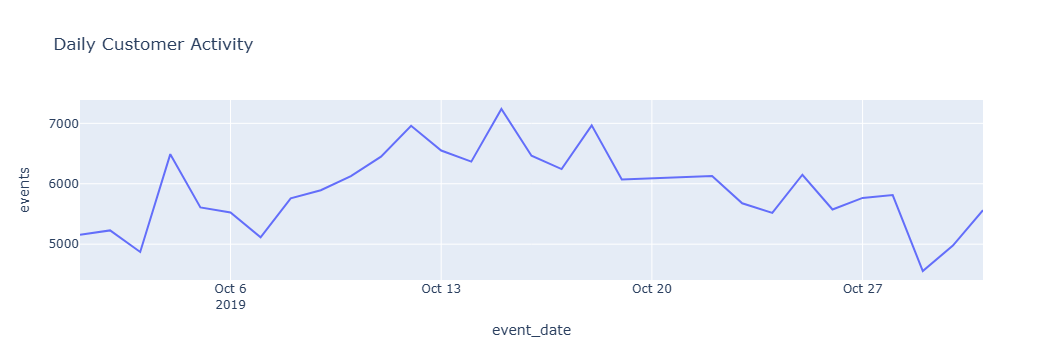

In [47]:
df['event_date'] = pd.to_datetime(df['event_date'])

daily_activity = (
    df.groupby('event_date')
      .size()
      .reset_index(name='events')
)

fig = px.line(
    daily_activity,
    x='event_date',
    y='events',
    title='Daily Customer Activity'
)

fig.show()

# <font color='red'>dataset loading for PowerBI </font>  

In [48]:
df.to_csv('funnel_powerbi.csv', index=False)